In [7]:
import matplotlib.pyplot as plt
import random
import itertools
from graph import (
    Graph, create_random_graph,
    has_cycle, is_connected, is_vertex_cover, MVC,
    BFS, DFS, BFS2, DFS2, BFS3, DFS3
)

In [8]:
def approx1(G):
    local_adj = {k: list(v) for k, v in G.adj.items()}
    C = []

    while True:
        covered = True
        for u in local_adj:
            for v in local_adj[u]:
                if u not in C and v not in C:
                    covered = False
                    break
            if not covered:
                break
        if covered:
            return C

        best_v = max(local_adj, key=lambda x: len(local_adj[x]))
        if len(local_adj[best_v]) == 0:
            break
        C.append(best_v)

        for nb in local_adj[best_v]:
            local_adj[nb] = [x for x in local_adj[nb] if x != best_v]
        local_adj[best_v] = []

    return C


def approx2(G):
    local_adj = {k: list(v) for k, v in G.adj.items()}
    nodes = list(G.adj.keys())
    random.shuffle(nodes)
    C = []

    for v in nodes:
        covered = True
        for u in local_adj:
            for nb in local_adj[u]:
                if u not in C and nb not in C:
                    covered = False
                    break
            if not covered:
                break
        if covered:
            return C
        C.append(v)

    return C


def approx3(G):
    local_adj = {k: list(v) for k, v in G.adj.items()}
    C = []

    while True:
        uncovered = [
            (u, v)
            for u in local_adj
            for v in local_adj[u]
            if u < v and u not in C and v not in C
        ]
        if not uncovered:
            break

        u, v = random.choice(uncovered)
        C.append(u)
        C.append(v)

        for node in [u, v]:
            for nb in local_adj[node]:
                local_adj[nb] = [x for x in local_adj[nb] if x != node]
            local_adj[node] = []

    return C

In [9]:
n_nodes   = 8
runs      = 1000
edge_vals = [1, 5, 10, 15, 20, 25, 28]

ratios1, ratios2, ratios3 = [], [], []

for m in edge_vals:
    sum_mvc = sum_a1 = sum_a2 = sum_a3 = 0

    for _ in range(runs):
        G = create_random_graph(n_nodes, m)
        mvc_size = max(len(MVC(G)), 1)   
        sum_mvc += mvc_size
        sum_a1  += len(approx1(G))
        sum_a2  += len(approx2(G))
        sum_a3  += len(approx3(G))

    ratios1.append(sum_a1 / sum_mvc)
    ratios2.append(sum_a2 / sum_mvc)
    ratios3.append(sum_a3 / sum_mvc)

print("m values :", edge_vals)
print("approx1  :", [round(r, 3) for r in ratios1])
print("approx2  :", [round(r, 3) for r in ratios2])
print("approx3  :", [round(r, 3) for r in ratios3])

m values : [1, 5, 10, 15, 20, 25, 28]
approx1  : [1.0, 1.015, 1.026, 1.007, 1.013, 1.0, 1.0]
approx2  : [2.996, 1.921, 1.555, 1.364, 1.26, 1.152, 1.0]
approx3  : [2.0, 1.794, 1.573, 1.425, 1.373, 1.29, 1.143]


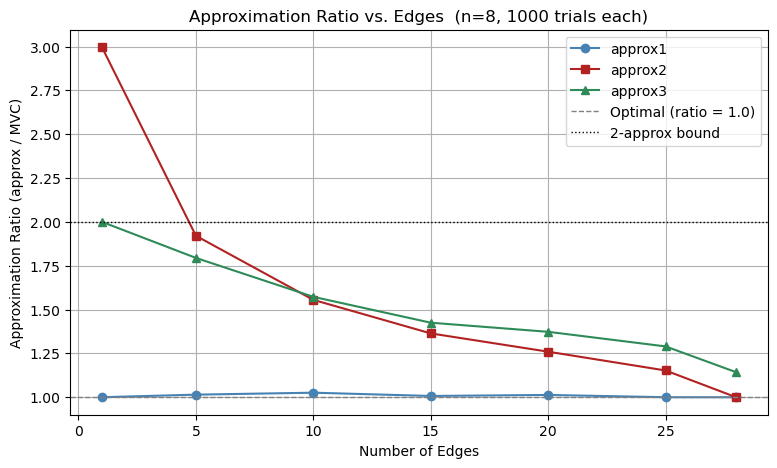

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(edge_vals, ratios1, 'o-', color='steelblue',   label='approx1')
plt.plot(edge_vals, ratios2, 's-', color='firebrick',   label='approx2')
plt.plot(edge_vals, ratios3, '^-', color='seagreen',    label='approx3')
plt.axhline(y=1.0, color='gray',  linestyle='--', linewidth=1, label='Optimal (ratio = 1.0)')
plt.axhline(y=2.0, color='black', linestyle=':',  linewidth=1, label='2-approx bound')
plt.xlabel('Number of Edges')
plt.ylabel('Approximation Ratio (approx / MVC)')
plt.title(f'Approximation Ratio vs. Edges  (n={n_nodes}, {runs} trials each)')
plt.legend()
plt.grid(True)
plt.savefig("approx_vs_edges.png", dpi=300)
plt.show()

In [11]:
node_vals = [5, 6, 7, 8, 9, 10]
runs_n    = 500

ratios1_n, ratios2_n, ratios3_n = [], [], []

for n in node_vals:
    m = max(1, n * (n - 1) // 4) 
    sum_mvc = sum_a1 = sum_a2 = sum_a3 = 0

    for _ in range(runs_n):
        G = create_random_graph(n, m)
        mvc_size = max(len(MVC(G)), 1)

        sum_mvc += mvc_size
        sum_a1  += len(approx1(G))
        sum_a2  += len(approx2(G))
        sum_a3  += len(approx3(G))

    ratios1_n.append(sum_a1 / sum_mvc)
    ratios2_n.append(sum_a2 / sum_mvc)
    ratios3_n.append(sum_a3 / sum_mvc)

print("n values :", node_vals)
print("approx1  :", [round(r, 3) for r in ratios1_n])
print("approx2  :", [round(r, 3) for r in ratios2_n])
print("approx3  :", [round(r, 3) for r in ratios3_n])

n values : [5, 6, 7, 8, 9, 10]
approx1  : [1.0, 1.03, 1.002, 1.009, 1.023, 1.028]
approx2  : [1.492, 1.472, 1.412, 1.41, 1.383, 1.373]
approx3  : [1.635, 1.582, 1.503, 1.443, 1.431, 1.415]


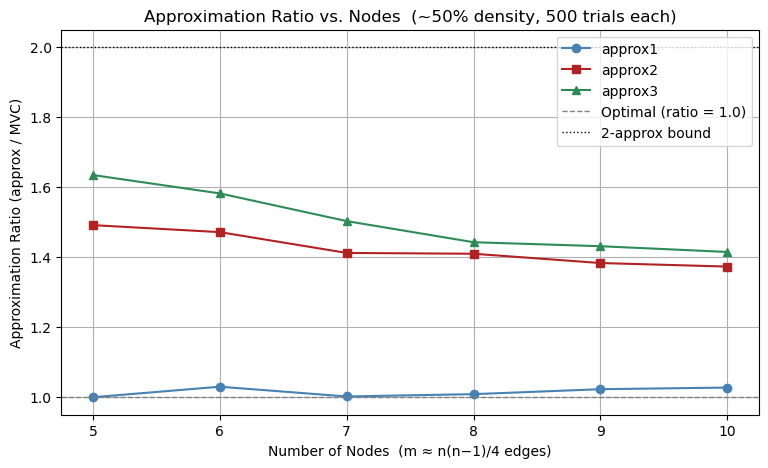

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(node_vals, ratios1_n, 'o-', color='steelblue',  label='approx1')
plt.plot(node_vals, ratios2_n, 's-', color='firebrick',  label='approx2')
plt.plot(node_vals, ratios3_n, '^-', color='seagreen',   label='approx3')
plt.axhline(y=1.0, color='gray',  linestyle='--', linewidth=1, label='Optimal (ratio = 1.0)')
plt.axhline(y=2.0, color='black', linestyle=':',  linewidth=1, label='2-approx bound')
plt.xlabel('Number of Nodes  (m ≈ n(n−1)/4 edges)')
plt.ylabel('Approximation Ratio (approx / MVC)')
plt.title(f'Approximation Ratio vs. Nodes  (~50% density, {runs_n} trials each)')
plt.legend()
plt.grid(True)
plt.savefig("approx_vs_nodes.png", dpi=300)
plt.show()